#  Practical 8 — Movie Review Sentiment Analysis


Step 1 : Importing **library**

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pickle

In [26]:
df = pd.read_csv('/content/IMDB Dataset.csv')

In [27]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [7]:
df.tail()

,review,sentiment
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative
49999,No one expects the Star Trek movies to be high...,negative


Step 2 : Dataset Exploration

In [28]:
print("=" * 55)
print("           DATASET EXPLORATION")
print("=" * 55)
print(f"Total Reviews  : {len(df)}")
print(f"Columns        : {list(df.columns)}")
print(f"\nMissing values :\n{df.isnull().sum()}")
print(f"\nSentiment Distribution:\n{df['sentiment'].value_counts()}")
print(f"\nSample review:\n{df['review'].iloc[0][:300]}...")

           DATASET EXPLORATION
Total Reviews  : 50000
Columns        : ['review', 'sentiment']

Missing values :
review       0
sentiment    0
dtype: int64

Sentiment Distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Sample review:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Tru...


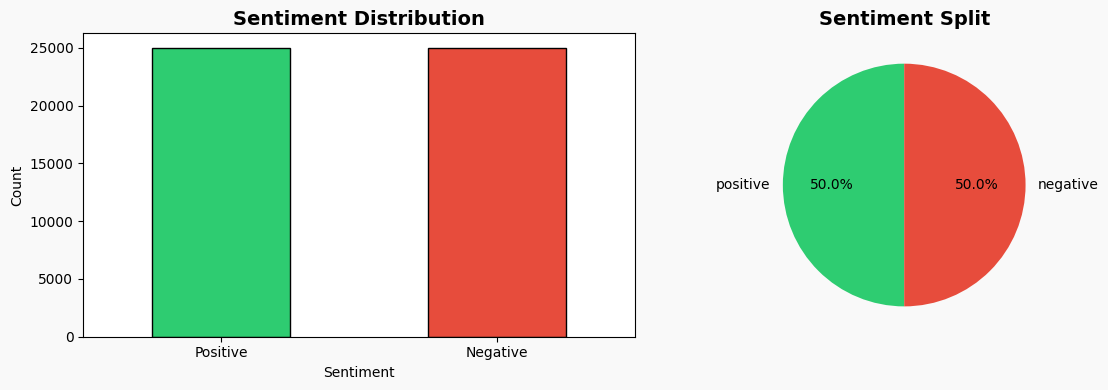

In [29]:
# ── Visualise distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor('#f9f9f9')

df['sentiment'].value_counts().plot(
    kind='bar', ax=axes[0],
    color=['#2ecc71', '#e74c3c'], edgecolor='black'
)
axes[0].set_title('Sentiment Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Positive', 'Negative'], rotation=0)

df['sentiment'].value_counts().plot(
    kind='pie', ax=axes[1],
    autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90
)
axes[1].set_title('Sentiment Split', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

Step 3: Text Preprocessing



In [15]:
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

In [17]:
stop_words = set(stopwords.words('english'))
stemmer    = PorterStemmer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [stemmer.stem(w) for w in tokens
              if w not in stop_words and len(w) > 1]
    return ' '.join(tokens)

print("Preprocessing 50,000 reviews")
df['cleaned_review'] = df['review'].apply(preprocess_text)



Preprocessing 50,000 reviews


In [18]:
print("\n" + "=" * 65)
print("           TEXT PREPROCESSING OUTPUT")
print("=" * 65)
for i in range(3):
    print(f"\n--- Review {i+1} ---")
    print(f"ORIGINAL  : {df['review'].iloc[i][:250]}...")
    print(f"CLEANED   : {df['cleaned_review'].iloc[i][:250]}...")

orig_avg  = df['review'].apply(lambda x: len(x.split())).mean()
clean_avg = df['cleaned_review'].apply(lambda x: len(x.split())).mean()
print(f"\nAvg token count — Original: {orig_avg:.0f}  →  Cleaned: {clean_avg:.0f}")


           TEXT PREPROCESSING OUTPUT

--- Review 1 ---
ORIGINAL  : One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of ...
CLEANED   : one review mention watch oz episod youll hook right exactli happen meth first thing struck oz brutal unflinch scene violenc set right word go trust show faint heart timid show pull punch regard drug sex violenc hardcor classic use wordit call oz nick...

--- Review 2 ---
ORIGINAL  : A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen...
CLEANED   : wonder littl product film techniqu unassum oldtimebbc fashion give comfort sometim discomfort sens realism entir pie

Step 4 : Encode Labels & TF-IDF Feature Extraction

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

In [20]:
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

X_train, X_test, y_train, y_test = train_test_split(
    df['cleaned_review'], df['label'],
    test_size=0.2, random_state=42, stratify=df['label']
)

print(f"Training samples : {len(X_train):,}")
print(f"Testing  samples : {len(X_test):,}")

Training samples : 40,000
Testing  samples : 10,000


In [21]:
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"TF-IDF matrix shape (train) : {X_train_tfidf.shape}")
print(f"TF-IDF matrix shape (test)  : {X_test_tfidf.shape}")
print(f"Total features              : {len(tfidf.vocabulary_):,}")

TF-IDF matrix shape (train) : (40000, 10000)
TF-IDF matrix shape (test)  : (10000, 10000)
Total features              : 10,000


Step 5 : Train All 5 Models

In [23]:
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Naive Bayes'         : MultinomialNB(),
    'SVM (LinearSVC)'     : LinearSVC(random_state=42, max_iter=2000),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=42,
                                                        learning_rate=0.1, max_depth=5),
}

results        = {}
trained_models = {}

In [30]:
for name, model in models.items():
    print(f"  ⏳  Training {name}...")
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)

    report = classification_report(y_test, y_pred, output_dict=True)
    results[name] = {
        'Accuracy'  : round(accuracy_score(y_test, y_pred) * 100, 2),
        'Precision' : round(report['weighted avg']['precision']  * 100, 2),
        'Recall'    : round(report['weighted avg']['recall']     * 100, 2),
        'F1-Score'  : round(report['weighted avg']['f1-score']   * 100, 2),
    }
    trained_models[name] = (model, y_pred)
    print(f" {name:25s}  Accuracy: {results[name]['Accuracy']}%")

  ⏳  Training Logistic Regression...
 Logistic Regression        Accuracy: 89.21%
  ⏳  Training Naive Bayes...
 Naive Bayes                Accuracy: 86.27%
  ⏳  Training SVM (LinearSVC)...
 SVM (LinearSVC)            Accuracy: 88.7%
  ⏳  Training Random Forest...
 Random Forest              Accuracy: 85.29%
  ⏳  Training Gradient Boosting...
 Gradient Boosting          Accuracy: 83.08%


Step 6 : Model Comparison

In [31]:
results_df = pd.DataFrame(results).T.reset_index()
results_df.columns = ['Model', 'Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)']
results_df = results_df.sort_values('Accuracy (%)', ascending=False).reset_index(drop=True)
results_df.index += 1

print("\n" + "=" * 72)
print("                    MODEL COMPARISON TABLE")
print("=" * 72)
print(results_df.to_string())
print("=" * 72)



                    MODEL COMPARISON TABLE
                 Model  Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%)
1  Logistic Regression         89.21          89.22       89.21         89.21
2      SVM (LinearSVC)         88.70          88.71       88.70         88.70
3          Naive Bayes         86.27          86.32       86.27         86.27
4        Random Forest         85.29          85.29       85.29         85.29
5    Gradient Boosting         83.08          83.25       83.08         83.06


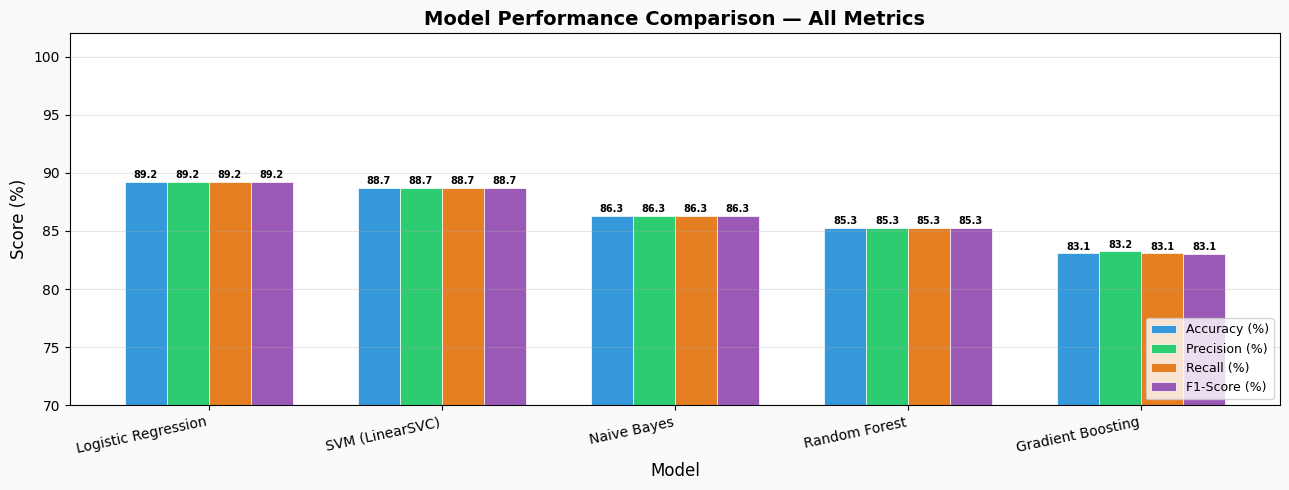

In [32]:
fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor('#fafafa')

x       = np.arange(len(results_df))
width   = 0.18
metrics = ['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)']
colors  = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + i * width, results_df[metric], width,
                  label=metric, color=color, edgecolor='white', linewidth=0.5)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
                f'{bar.get_height():.1f}', ha='center', va='bottom',
                fontsize=7, fontweight='bold')

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Model Performance Comparison — All Metrics', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_df['Model'], rotation=12, ha='right', fontsize=10)
ax.set_ylim(70, 102)
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Step 7 : Confusion Matrices

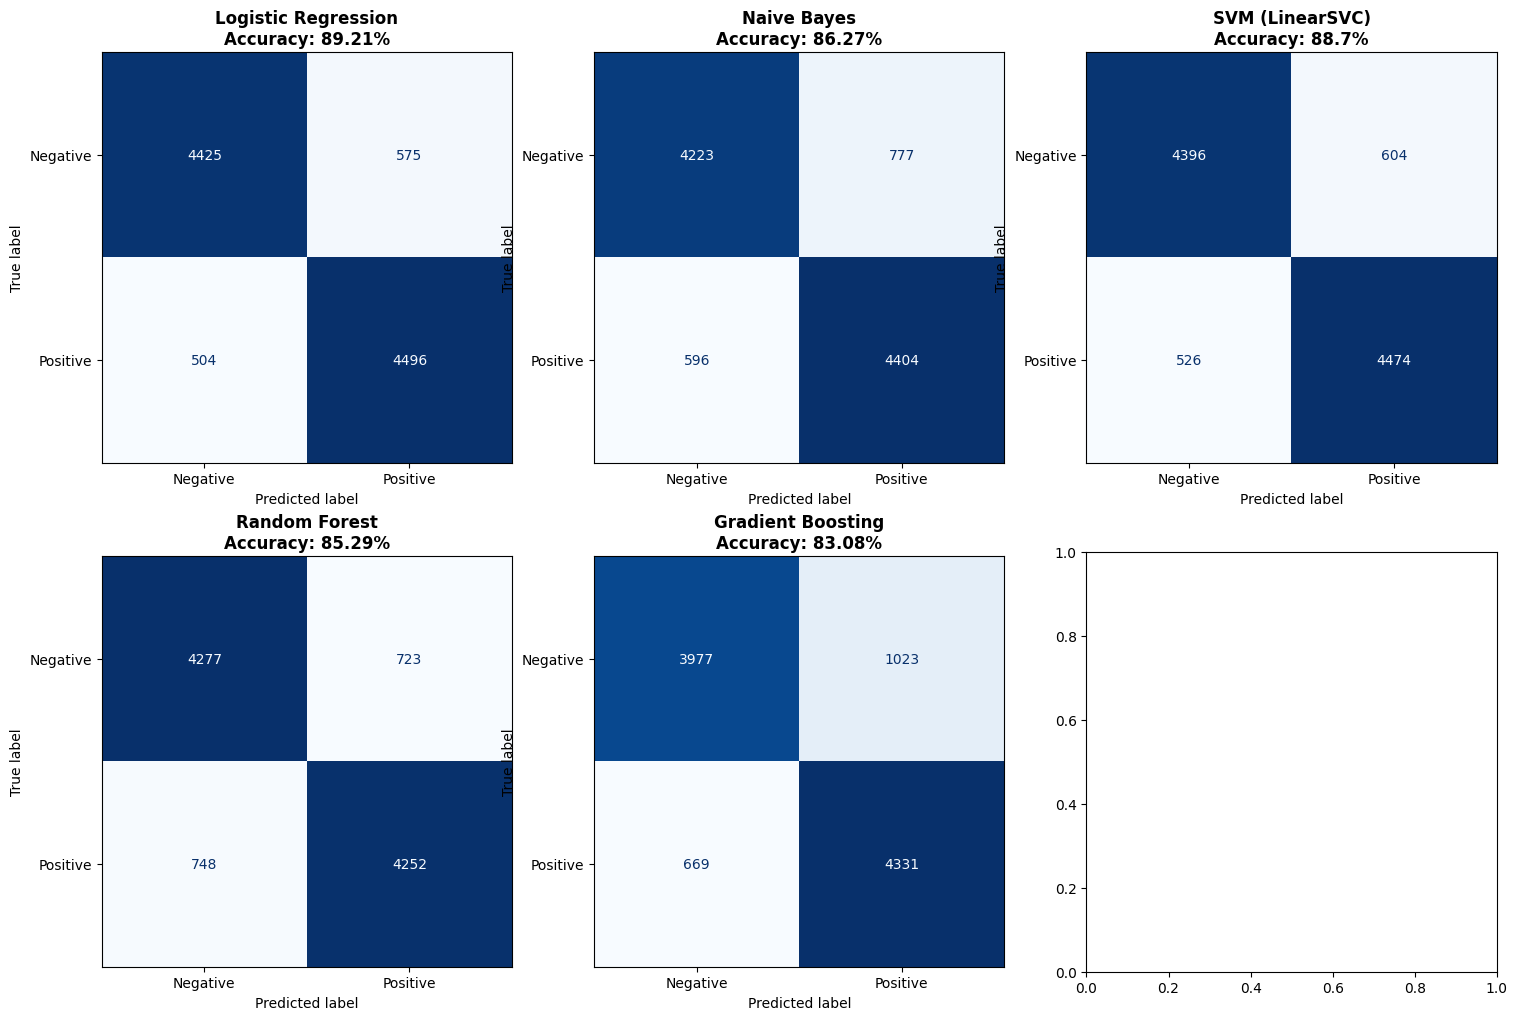

In [35]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (name, (model, y_pred)) in enumerate(trained_models.items()):
    cm   = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Negative', 'Positive'])
    disp.plot(ax=axes[idx], colorbar=False, cmap='Blues')
    axes[idx].set_title(
        f'{name}\nAccuracy: {results[name]["Accuracy"]}%',
        fontsize=12, fontweight='bold'
    )

In [36]:
axes[5].set_visible(False)

plt.suptitle('Confusion Matrices — All 5 Models',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrices complete!")

<Figure size 640x480 with 0 Axes>

✅ Confusion matrices complete!


Step 8 : Best Model Selection

In [37]:
best_model_name = results_df.iloc[0]['Model']
best_accuracy   = results_df.iloc[0]['Accuracy (%)']
best_model_obj  = trained_models[best_model_name][0]
y_pred_best     = trained_models[best_model_name][1]

print("\n" + "=" * 55)
print("            BEST MODEL SELECTION")
print("=" * 55)
print(f"\n  🏆  Best Model  : {best_model_name}")
print(f"      Accuracy    : {best_accuracy}%")
print(f"      F1-Score    : {results_df.iloc[0]['F1-Score (%)']}%")
print(f"      Precision   : {results_df.iloc[0]['Precision (%)']}%")
print(f"      Recall      : {results_df.iloc[0]['Recall (%)']}%")
print("=" * 55)


            BEST MODEL SELECTION

  🏆  Best Model  : Logistic Regression
      Accuracy    : 89.21%
      F1-Score    : 89.21%
      Precision   : 89.22%
      Recall      : 89.21%


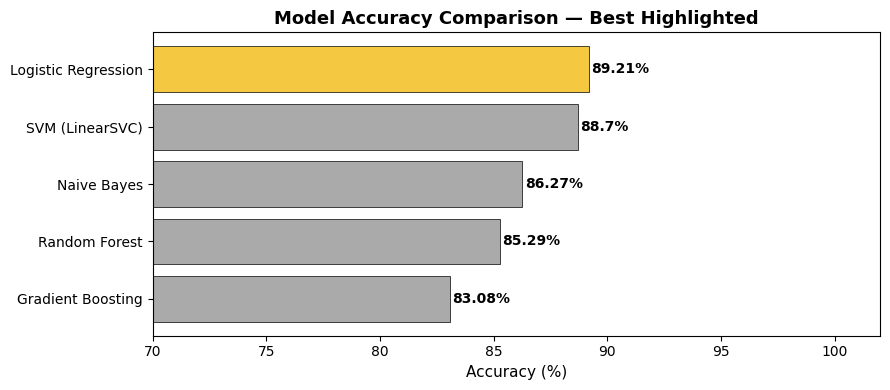


📋 Full Classification Report — Logistic Regression:
              precision    recall  f1-score   support

    Negative       0.90      0.89      0.89      5000
    Positive       0.89      0.90      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [38]:
fig, ax = plt.subplots(figsize=(9, 4))
colors_bar = ['#f5c842' if n == best_model_name else '#aaaaaa'
              for n in results_df['Model']]
bars = ax.barh(results_df['Model'], results_df['Accuracy (%)'],
               color=colors_bar, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, results_df['Accuracy (%)']):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontweight='bold', fontsize=10)
ax.set_xlabel('Accuracy (%)', fontsize=11)
ax.set_title('Model Accuracy Comparison — Best Highlighted', fontsize=13, fontweight='bold')
ax.set_xlim(70, 102)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('best_model_selection.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📋 Full Classification Report — {best_model_name}:")
print(classification_report(y_test, y_pred_best,
      target_names=['Negative', 'Positive']))

Step 9 : Vectorize best model

In [39]:
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model_obj, f)

with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

meta = {
    'best_model_name': best_model_name,
    'best_accuracy'  : best_accuracy,
    'all_results'    : results
}
with open('model_metadata.pkl', 'wb') as f:
    pickle.dump(meta, f)

print(f"  Saved: best_model.pkl       ({best_model_name})")
print(f"  Saved: tfidf_vectorizer.pkl")
print(f"  Saved: model_metadata.pkl")
print()

  Saved: best_model.pkl       (Logistic Regression)
  Saved: tfidf_vectorizer.pkl
  Saved: model_metadata.pkl



Testing : Prediction Test

In [41]:
def predict_sentiment(review_text):
    cleaned    = preprocess_text(review_text)
    vectorized = tfidf.transform([cleaned])
    pred       = best_model_obj.predict(vectorized)[0]
    return "POSITIVE " if pred == 1 else "NEGATIVE "

test_reviews = [
    "This movie was absolutely fantastic! The acting was superb and the story deeply moving.",
    "Terrible film. Boring plot, bad acting and wooden characters. Total waste of time.",
    "It was okay — not great but not terrible either. Some good scenes, some dull ones.",
    "A masterpiece of modern cinema. Beautifully shot and brilliantly acted throughout.",
    "I walked out after 30 minutes. The worst movie I have seen in years.",
]

print("\n" + "=" * 65)
print("               QUICK PREDICTION TEST")
print("=" * 65)
for i, rev in enumerate(test_reviews, 1):
    result = predict_sentiment(rev)
    print(f"\n[{i}] {rev[:75]}")
    print(f"    → {result}")

print(f"\n\n{'='*65}")
print(f"   Best model : {best_model_name}  |  Accuracy : {best_accuracy}%")
print(f"{'='*65}")


               QUICK PREDICTION TEST

[1] This movie was absolutely fantastic! The acting was superb and the story de
    → POSITIVE 

[2] Terrible film. Boring plot, bad acting and wooden characters. Total waste o
    → NEGATIVE 

[3] It was okay — not great but not terrible either. Some good scenes, some dul
    → NEGATIVE 

[4] A masterpiece of modern cinema. Beautifully shot and brilliantly acted thro
    → POSITIVE 

[5] I walked out after 30 minutes. The worst movie I have seen in years.
    → NEGATIVE 


   Best model : Logistic Regression  |  Accuracy : 89.21%


In [42]:
# Run this in Colab to download all 3 pkl files
from google.colab import files
files.download('best_model.pkl')
files.download('tfidf_vectorizer.pkl')
files.download('model_metadata.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>